In [8]:
import pickle
import scipy.signal
from scipy import signal
import h5py
import numpy as np

import sys
sys.path.append('./PyZapline_plus/pyZapline_plus')  
import pyzaplineplus

In [ ]:
def load_ssvep_data(file_path):
    """
    Load EEG-Data and Trigger from .mat v7.3 (HDF5)
    """
    with h5py.File(file_path, "r") as f:
        raw_data = f["y"][:]              
        eegs     = raw_data[:, 1:9]       # CH2 bis CH9 → EEG
        triggers = raw_data[:, 9]         # CH10 → Trigger (LED on/off)

    return eegs, triggers

# load data
eeg_data, trigger_data = load_ssvep_data("ssvep/subject_1_fvep_led_training_1.mat")

print("EEG shape:", eeg_data.shape)
print("Trigger shape:", trigger_data.shape)
# mne - maybe transponse to (n_channels, n_samples) - for ICA, CSP etc

EEG shape: (57728, 8)
Trigger shape: (57728,)


numpy.ndarray

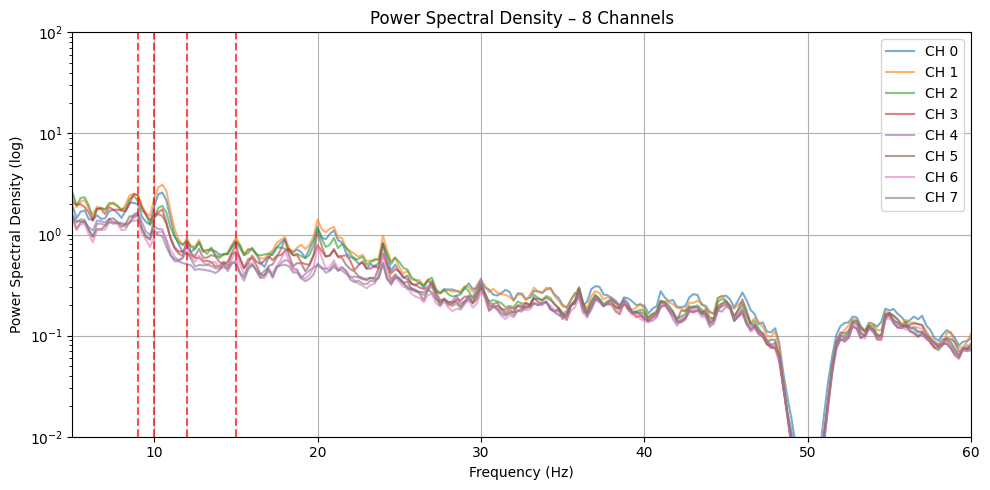

In [ ]:
# Power Spectral Density (PSD) Analysis

import matplotlib.pyplot as plt
from scipy.signal import welch

plt.figure(figsize=(10, 5))

for ch in range(eeg_data.shape[1]):
    freqs, psd = welch(eeg_data[:, ch], fs=256, nperseg=1024)
    plt.semilogy(freqs, psd, label=f"CH {ch}", alpha=0.6)

# SSVEP-Frequencies
for target_freq in [9, 10, 12, 15]:
    plt.axvline(x=target_freq, color='red', linestyle='--', alpha=0.7)

plt.xlim(5, 60)  # x - Frequency
plt.ylim(1e-2, 1e2)  # y - Power 
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (log)")
plt.title("Power Spectral Density – 8 Channels")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()